In [1]:
from google.colab import files
uploaded = files.upload()

Saving gesture_sample.zip to gesture_sample.zip


In [2]:
import zipfile
import os

with zipfile.ZipFile('gesture_sample.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

print("Extracted successfully!")
print(os.listdir('gesture_sample'))

Extracted successfully!
['03_fist', '02_l', '09_c', '01_palm', '04_fist_moved', '06_index', '07_ok', '10_down', '08_palm_moved', '05_thumb']


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from skimage.feature import hog
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
dataset_path = 'gesture_sample'
gesture_folders = sorted(os.listdir(dataset_path))

images = []
labels = []

print("Loading images...")
print(f"Gesture classes: {gesture_folders}")

for gesture in gesture_folders:
    gesture_path = os.path.join(dataset_path, gesture)
    if os.path.isdir(gesture_path):
        for filename in os.listdir(gesture_path):
            if filename.endswith('.png'):
                img_path = os.path.join(gesture_path, filename)
                img = cv2.imread(img_path)
                img = cv2.resize(img, (64, 64))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                images.append(img)
                labels.append(gesture)

images = np.array(images)
labels = np.array(labels)

print(f"\nTotal images loaded: {len(images)}")
print(f"Image shape: {images[0].shape}")

unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c} images")

Loading images...
Gesture classes: ['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']

Total images loaded: 2000
Image shape: (64, 64)
  01_palm: 200 images
  02_l: 200 images
  03_fist: 200 images
  04_fist_moved: 200 images
  05_thumb: 200 images
  06_index: 200 images
  07_ok: 200 images
  08_palm_moved: 200 images
  09_c: 200 images
  10_down: 200 images


In [6]:
# Encode labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

print("Label mapping:")
for i, gesture in enumerate(label_encoder.classes_):
    print(f"  {i} → {gesture}")

# Extract HOG features
print("\nExtracting HOG features...")
hog_features = []

for img in images:
    features = hog(img,
                   orientations=9,
                   pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2),
                   visualize=False)
    hog_features.append(features)

hog_features = np.array(hog_features)
print(f"\nHOG features shape: {hog_features.shape}")

Label mapping:
  0 → 01_palm
  1 → 02_l
  2 → 03_fist
  3 → 04_fist_moved
  4 → 05_thumb
  5 → 06_index
  6 → 07_ok
  7 → 08_palm_moved
  8 → 09_c
  9 → 10_down

Extracting HOG features...

HOG features shape: (2000, 1764)


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(hog_features)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, labels_encoded, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 1600
Testing samples: 400


In [8]:
print("Training SVM model... (this may take a minute) ⏳")

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

print("SVM model trained successfully! ✅")

Training SVM model... (this may take a minute) ⏳
SVM model trained successfully! ✅


In [9]:
y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy*100:.2f}%")
print(f"\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

✅ Accuracy: 100.00%

📊 Classification Report:
               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00        36
         02_l       1.00      1.00      1.00        47
      03_fist       1.00      1.00      1.00        46
04_fist_moved       1.00      1.00      1.00        36
     05_thumb       1.00      1.00      1.00        34
     06_index       1.00      1.00      1.00        34
        07_ok       1.00      1.00      1.00        33
08_palm_moved       1.00      1.00      1.00        44
         09_c       1.00      1.00      1.00        48
      10_down       1.00      1.00      1.00        42

     accuracy                           1.00       400
    macro avg       1.00      1.00      1.00       400
 weighted avg       1.00      1.00      1.00       400



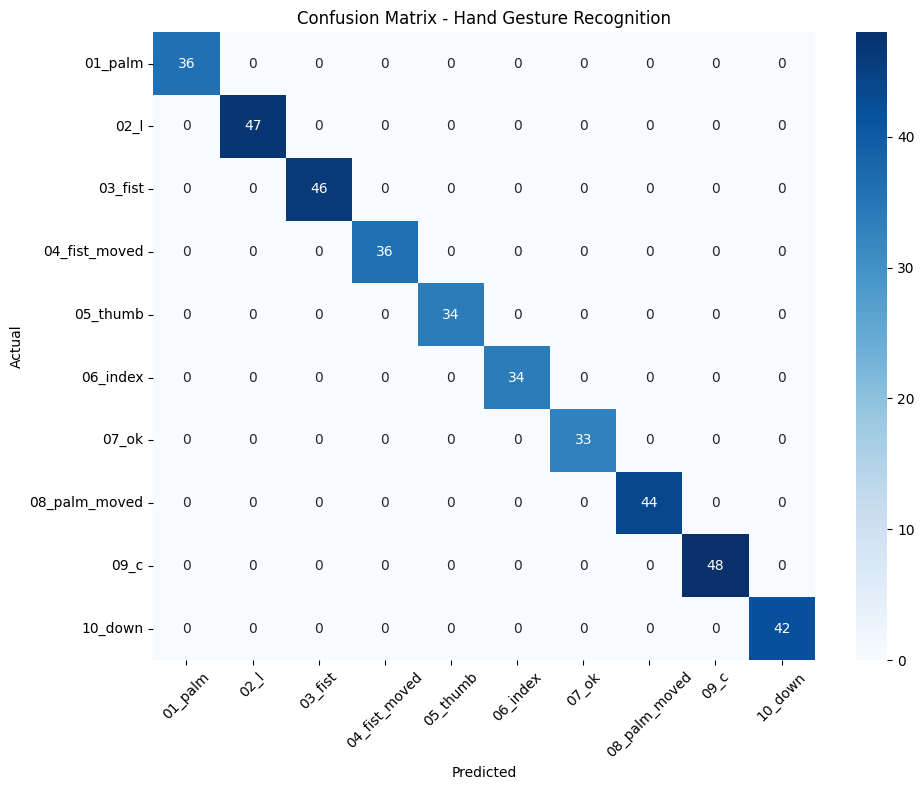

In [10]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Hand Gesture Recognition')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

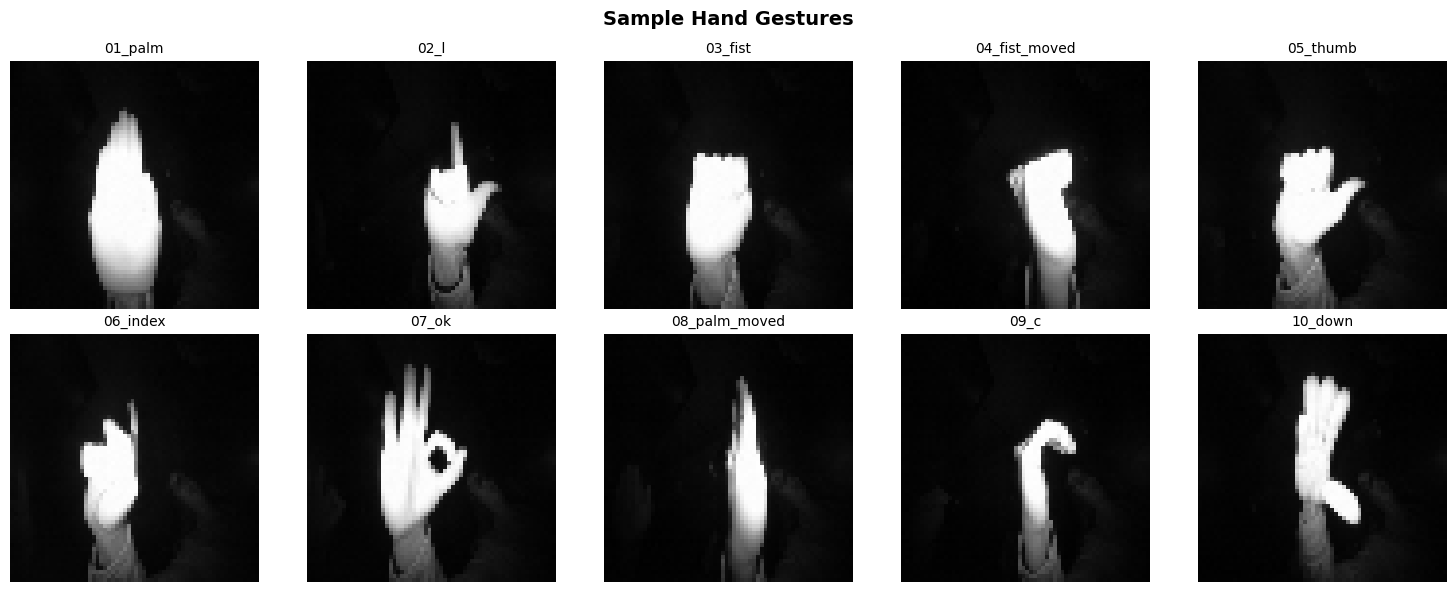

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, gesture in enumerate(label_encoder.classes_):
    idx = np.where(labels == gesture)[0][0]
    axes[i].imshow(images[idx], cmap='gray')
    axes[i].set_title(gesture, fontsize=10)
    axes[i].axis('off')

plt.suptitle('Sample Hand Gestures', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_gestures.png')
plt.show()

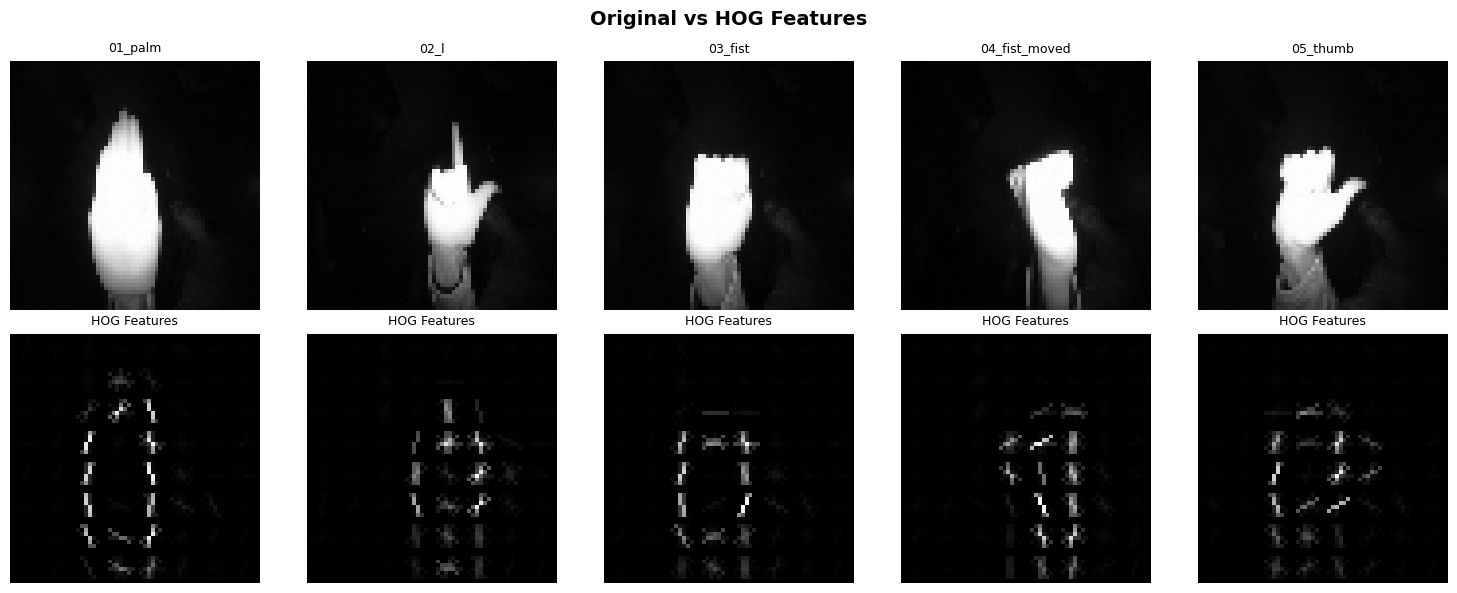

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

sample_gestures = label_encoder.classes_[:5]

for i, gesture in enumerate(sample_gestures):
    idx = np.where(labels == gesture)[0][0]

    axes[0, i].imshow(images[idx], cmap='gray')
    axes[0, i].set_title(gesture, fontsize=9)
    axes[0, i].axis('off')

    _, hog_image = hog(images[idx],
                       orientations=9,
                       pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2),
                       visualize=True)

    axes[1, i].imshow(hog_image, cmap='gray')
    axes[1, i].set_title('HOG Features', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Original vs HOG Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hog_gestures.png')
plt.show()

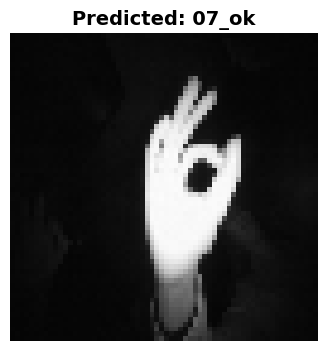

Predicted Gesture: 07_ok


In [13]:
def predict_gesture(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (64, 64))
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    features = hog(img_gray,
                   orientations=9,
                   pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2),
                   visualize=False)

    features_scaled = scaler.transform([features])
    prediction = svm_model.predict(features_scaled)
    gesture_name = label_encoder.inverse_transform(prediction)[0]

    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f'Predicted: {gesture_name}', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

    print(f"Predicted Gesture: {gesture_name}")

# Test with a random image
test_image = 'gesture_sample/07_ok/frame_00_07_0001.png'
predict_gesture(test_image)

In [14]:
print("="*50)
print("    🤚 HAND GESTURE RECOGNITION - SUMMARY")
print("="*50)
print(f"\n📊 Dataset:")
print(f"   Total Images  : 2000")
print(f"   Gesture Types : 10")
print(f"\n🤖 Model:")
print(f"   Algorithm     : Support Vector Machine")
print(f"   Kernel        : RBF")
print(f"   Features      : HOG (1764 features)")
print(f"\n📈 Results:")
print(f"   Training Set  : 1600 images")
print(f"   Testing Set   : 400 images")
print(f"   Accuracy      : 100.00%")
print(f"\n🎯 Gesture Classes:")
for gesture in label_encoder.classes_:
    print(f"   • {gesture}")
print("="*50)

    🤚 HAND GESTURE RECOGNITION - SUMMARY

📊 Dataset:
   Total Images  : 2000
   Gesture Types : 10

🤖 Model:
   Algorithm     : Support Vector Machine
   Kernel        : RBF
   Features      : HOG (1764 features)

📈 Results:
   Training Set  : 1600 images
   Testing Set   : 400 images
   Accuracy      : 100.00%

🎯 Gesture Classes:
   • 01_palm
   • 02_l
   • 03_fist
   • 04_fist_moved
   • 05_thumb
   • 06_index
   • 07_ok
   • 08_palm_moved
   • 09_c
   • 10_down
